In [ ]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers import *

In [115]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [116]:
N_order = 1               # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
alpha = np.arcsin(num_apt / n)

#20 microns
L_ffp = 0.02
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * f * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

In [117]:
f = np.load("images/usaf_resolution.npy")

In [118]:
true_modes = [[0, 4]]
true_c = [0.1]
true_aberration = Aberration(true_modes, true_c)

In [119]:
def add_gaussian_noise(image, mean, std_dev, rng):
    return image + rng.normal(mean, std_dev, np.shape(image))

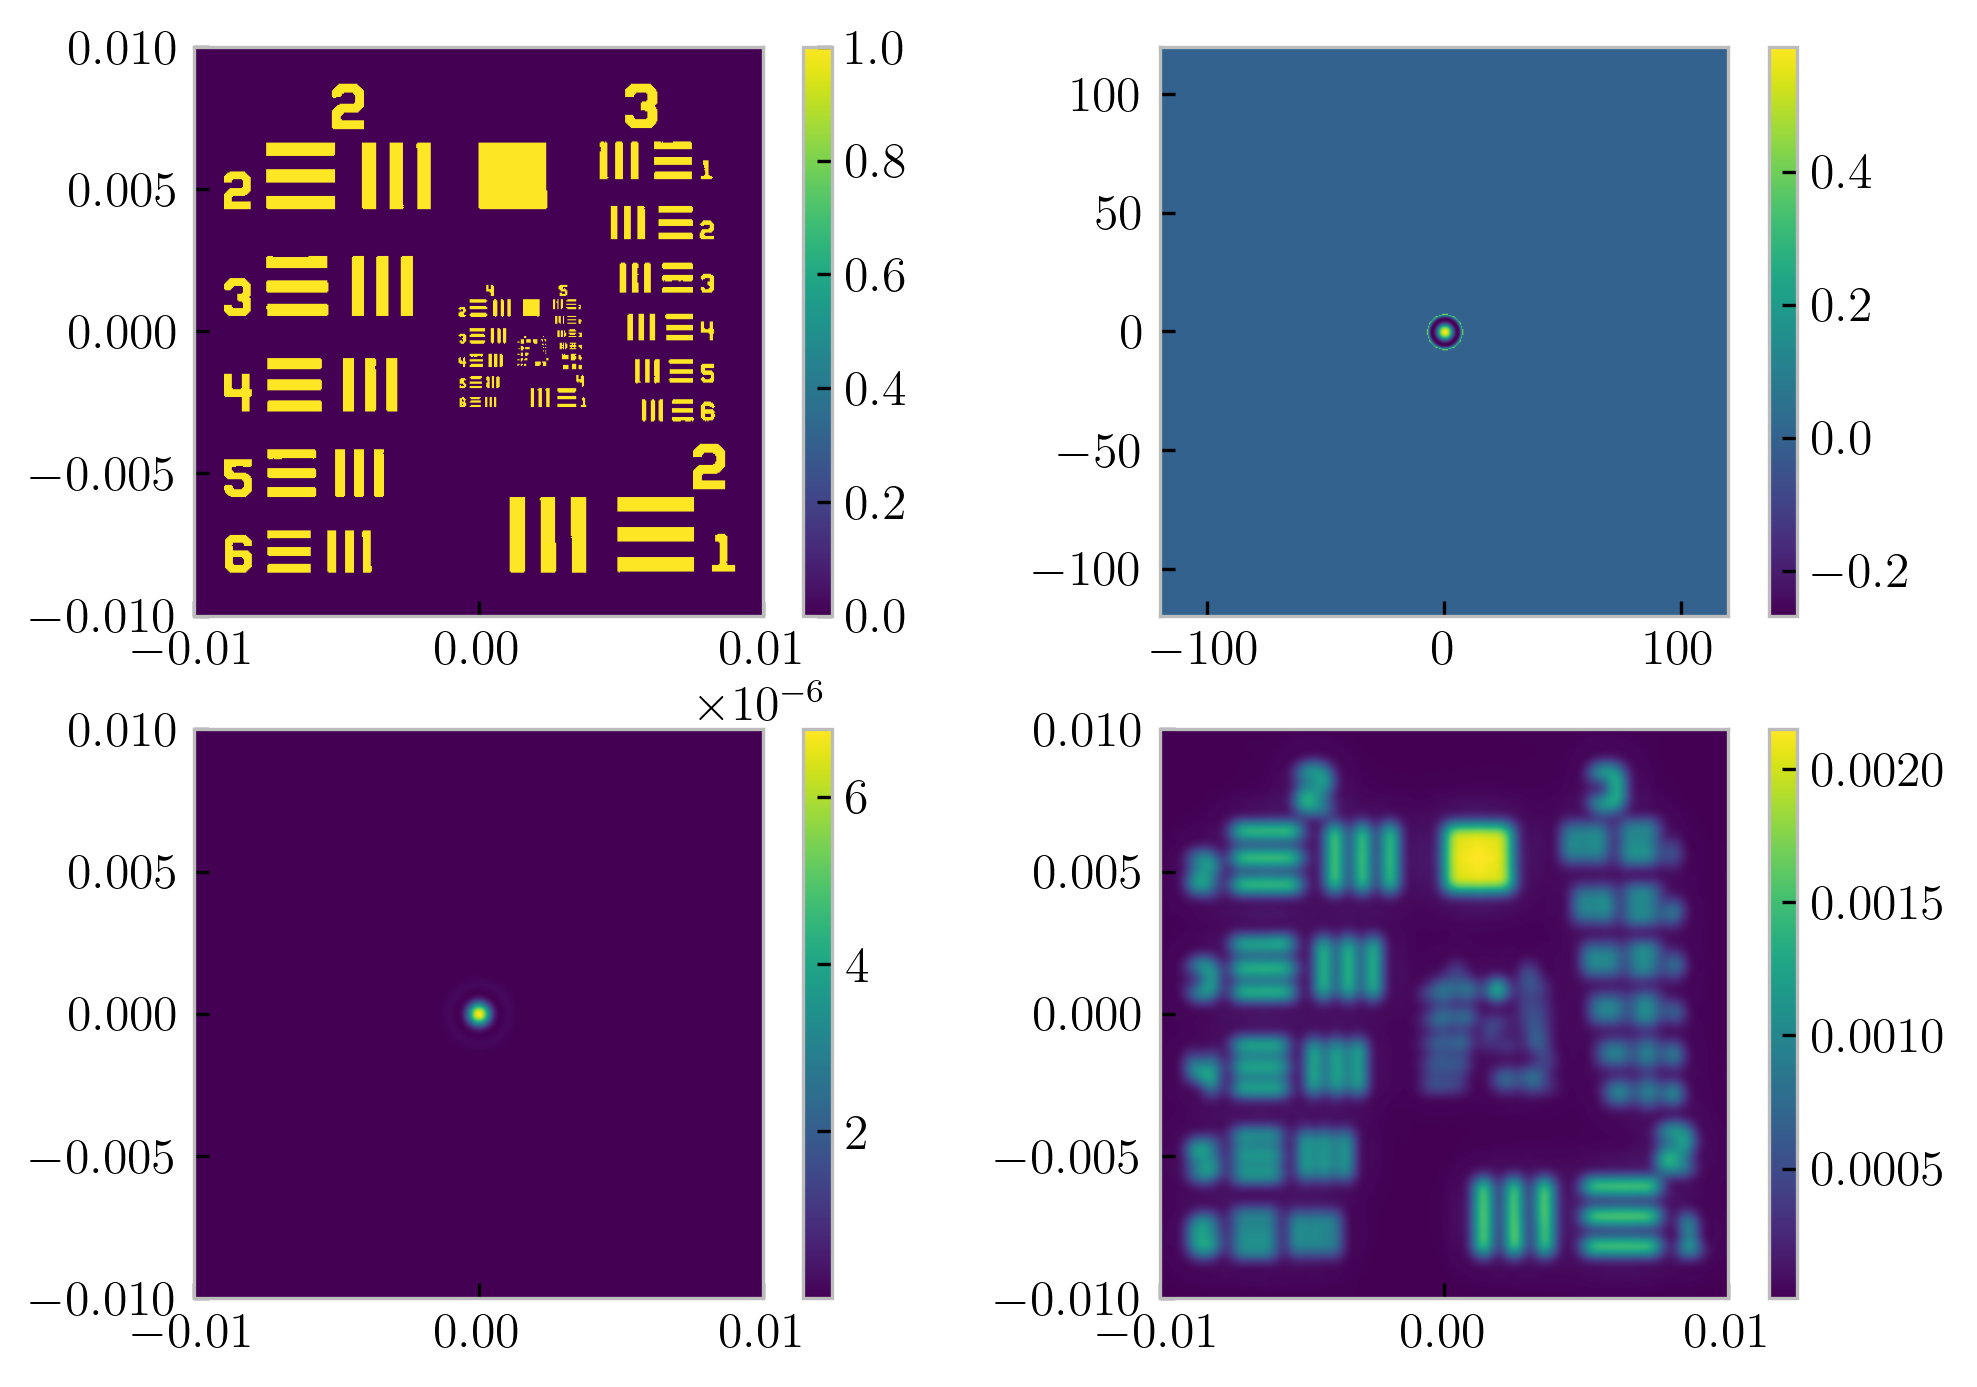

In [120]:
rng = np.random.default_rng(15)
mean = 0
std_dev = .5e-17

H = forward_H(microscope, true_aberration)
PSF = forward_PSF(microscope, true_aberration)
#plot_intensity(x, y, PSF, normalize = False)
d = forward_image(microscope, f, true_aberration)
#d = add_gaussian_noise(d, mean, std_dev, rng)
#plot_intensity(x, y, d, normalize = False)

fig, axs = plt.subplots(2, 2)
axs = axs.flatten()

im0 = axs[0].imshow(f,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im1 = axs[1].imshow(np.imag(H),
                    extent=[x_bfp[0], x_bfp[-1], y_bfp[0], y_bfp[-1]],)

im2 = axs[2].imshow(PSF,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im3= axs[3].imshow(d,
                   extent=[x[0], x[-1], y[0], y[-1]],)

for ax in axs:
    ax.grid(False)
    #ax.set_xticks([])
    #ax.set_yticks([])



fig.colorbar(im0, ax = axs[0])
fig.colorbar(im1, ax = axs[1])
fig.colorbar(im2, ax = axs[2])
fig.colorbar(im3, ax = axs[3])

In [121]:
bias_modes = [[0,4], [-2,2]]
bias_strength = 0.5
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]
d_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
#d_stack = [add_gaussian_noise(d, mean, std_dev, rng) for d in d_stack]

IndexError: index 13 is out of bounds for axis 0 with size 13

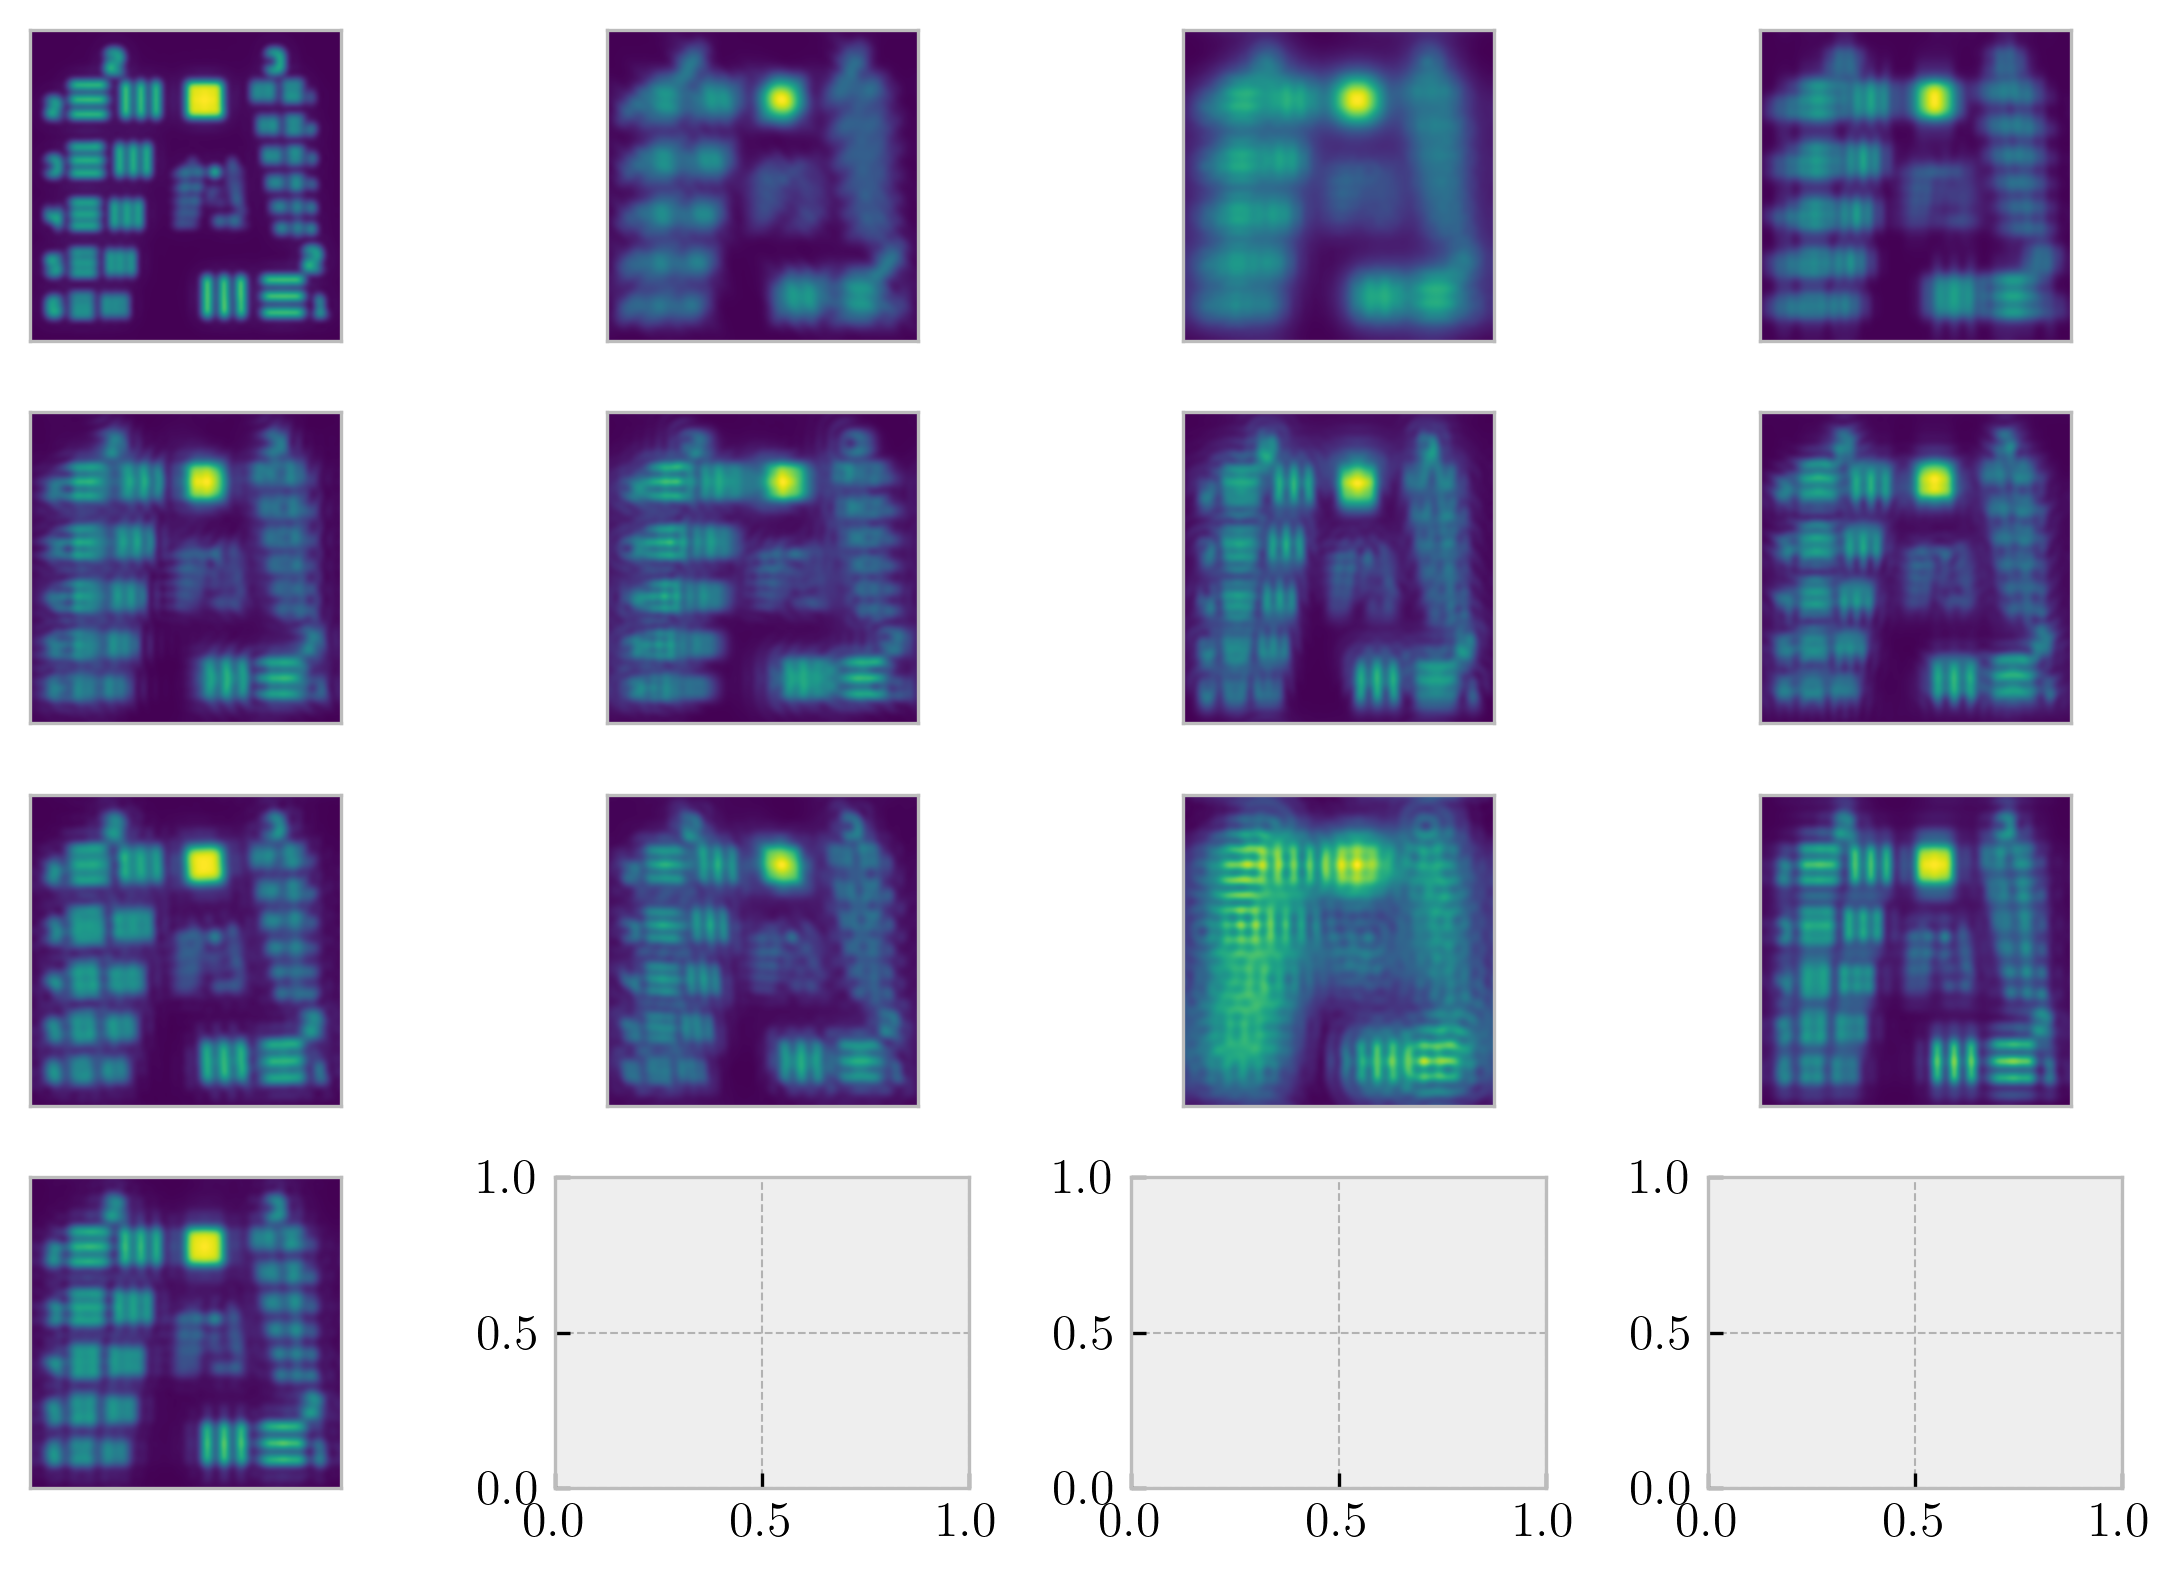

In [109]:
a = 4
b = 4
fig, axs = plt.subplots(a, b, layout = "tight")
axs = axs.flatten()
for i in range(a*b):
    axs[i].imshow(d_stack[i])
    axs[i].grid(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [ ]:
modes_corrected = true_modes

params = {
    "gamma": 0,
    "rate": 1,
    "threshold" : np.inf,
    "threshold_damper": 1,
}

c_guess, F_guess, c_guess_log, F_guess_log, J_log  = loop_optimize(n_loops = 25,
                                 microscope = microscope,
                                 d_stack = d_stack,
                                 a_stack = a_stack,
                                 modes_corrected = modes_corrected,
                                 params = params,
                                 debug = True,
                                 log = True)


  0%|          | 0/100 [00:00<?, ?it/s]

	 Estimated object in 0.335 seconds
	 Estimated gradient in 0.362 seconds
	 Estimated Hessian in 1.473 seconds


  1%|          | 1/100 [00:02<04:13,  2.56s/it]

Loop 1: J = 4397446364455.3906
Corrercted Zernike Mode: [[0, 4]]
Estimated Zernike Coefficients: [0.09724035]
	 Estimated object in 0.223 seconds
	 Estimated gradient in 0.339 seconds
	 Estimated Hessian in 1.457 seconds


  2%|▏         | 2/100 [00:04<04:01,  2.47s/it]

...

Loop 5: J = 291.0383
Corrercted Zernike Mode: [[0, 4]]
Estimated Zernike Coefficients: [0.1]
	 Estimated object in 0.225 seconds
	 Estimated gradient in 0.323 seconds
	 Estimated Hessian in 1.599 seconds


  6%|▌         | 6/100 [00:14<03:40,  2.35s/it]

Loop 6: J = 291.0383
Corrercted Zernike Mode: [[0, 4]]
Estimated Zernike Coefficients: [0.1]
	 Estimated object in 0.234 seconds
	 Estimated gradient in 0.331 seconds


  6%|▌         | 6/100 [00:15<04:07,  2.63s/it]


KeyboardInterrupt: 